In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv('penguins.csv')
df

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,NaN,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...
339,NaN,NaN,NaN,NaN,NaN
340,46.8,14.3,215.0,4850.0,FEMALE
341,50.4,15.7,222.0,5750.0,MALE
342,45.2,14.8,212.0,5200.0,FEMALE


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   342 non-null    float64
 1   culmen_depth_mm    342 non-null    float64
 2   flipper_length_mm  342 non-null    float64
 3   body_mass_g        342 non-null    float64
 4   sex                335 non-null    object 
dtypes: float64(4), object(1)
memory usage: 13.6+ KB


In [4]:
df.isnull().sum()

culmen_length_mm     2
culmen_depth_mm      2
flipper_length_mm    2
body_mass_g          2
sex                  9
dtype: int64

In [5]:
penguins_df = df.dropna()

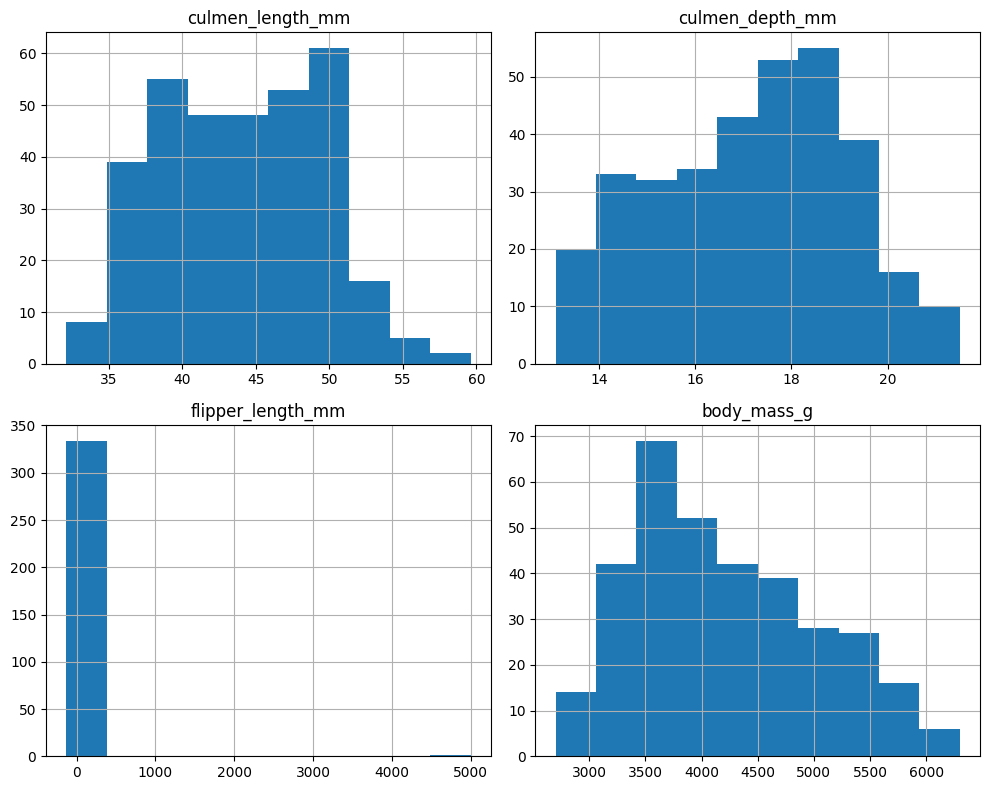

In [6]:
penguins_df.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

In [7]:
penguins_df.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,335.000000,335.000000,335.000000,335.000000
mean,43.988358,17.169552,214.355224,4209.179104
std,5.453430,1.971966,263.253508,803.633495
min,32.100000,13.100000,-132.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.550000,18.700000,213.000000,4787.500000
max,59.600000,21.500000,5000.000000,6300.000000


In [8]:
penguins_df[penguins_df["flipper_length_mm"] > 4000]

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
9,42.0,20.2,5000.0,4250.0,MALE


In [9]:
penguins_df[penguins_df["flipper_length_mm"] < 0]

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
14,34.6,21.1,-132.0,4400.0,MALE


In [10]:
penguins_clean = penguins_df.drop([9, 14])

In [11]:
le = LabelEncoder()
penguins_clean['sex'] = le.fit_transform(penguins_clean['sex'])

In [12]:
penguins_clean.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,2
1,39.5,17.4,186.0,3800.0,1
2,40.3,18.0,195.0,3250.0,1
4,36.7,19.3,193.0,3450.0,1
5,39.3,20.6,190.0,3650.0,2


In [14]:
penguins_clean.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
count,333.000000,333.000000,333.000000,333.000000,333.000000
mean,44.022523,17.148649,201.024024,4208.483483,1.498498
std,5.444308,1.958940,14.042299,805.978992,0.506730
min,32.100000,13.100000,172.000000,2700.000000,0.000000
25%,39.500000,15.600000,190.000000,3550.000000,1.000000
50%,44.500000,17.300000,197.000000,4050.000000,2.000000
75%,48.600000,18.700000,213.000000,4800.000000,2.000000
max,59.600000,21.500000,231.000000,6300.000000,2.000000


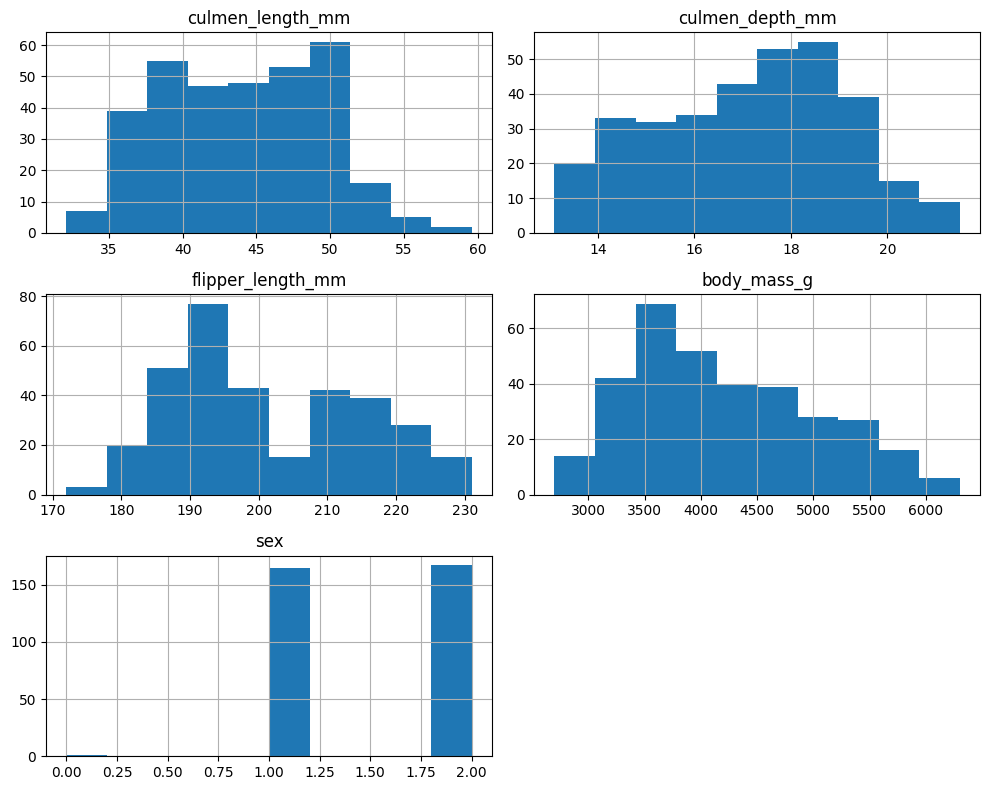

In [15]:
penguins_clean.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

In [17]:
scaler = StandardScaler()
X = scaler.fit_transform(penguins_clean)
penguins_preprocessed = pd.DataFrame(data=X, columns=penguins_clean.columns)
penguins_preprocessed.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,-0.905520,0.793126,-1.428125,-0.569709,0.991172
1,-0.831938,0.128503,-1.071522,-0.507579,-0.985237
2,-0.684775,0.435252,-0.429637,-1.191006,-0.985237
3,-1.347011,1.099875,-0.572278,-0.942487,-0.985237
4,-0.868729,1.764498,-0.786240,-0.693968,0.991172


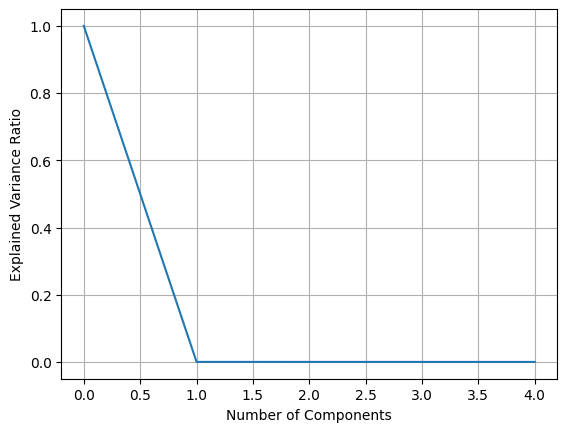

In [18]:
pca = PCA(n_components=penguins_clean.shape[1])  # Set to match or exceed feature count

pca.fit(penguins_clean)

explained_variance = pca.explained_variance_ratio_

plt.plot(explained_variance)
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()